# A robust fetal ECG detection method for abdominal recordings
Sequential-analysis pipeline for isolating the fetal ECG from multi-channel abdominal recordings, benchmarked against an independent component analysis (ICA) baseline.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
from scipy import signal
import wfdb
import glob
from sklearn.decomposition import FastICA

sys.path.append(os.path.abspath('../src'))
from filtering import BaselineWanderRemover, AdaptivePLICanceller
from preprocessing import SignalResampler
from mecg_canceller import MECGCanceller
from fecg_extractor import FECGExtractor
from utils import (compute_fhr, compute_fhr_series, compute_fhr_reliability, compute_success_rate,
                   load_ground_truth_peaks, match_peaks_to_gt, precision_recall_f1,
                   compute_snr_sir, compute_fhr_coverage, compute_fhr_mae_rmse,
                   spearman_with_ci)

from plotting import (plot_filter_transfer_function, plot_qrs_detection_dual, plot_pipeline_stages, plot_ica_stages,
                      plot_fhr_traces, plot_performance_summary, plot_detection_validation,
                      plot_ground_truth_validation, plot_snr_sir_vs_reliability, plot_reliability_correlation_matrix,
                      plot_before_after_comprehensive, plot_fhr_accuracy, plot_tolerance_sensitivity)

## Data Loading and Preprocessing

In [2]:
data_dir = '../data/set_a/'
hea_files = glob.glob(os.path.join(data_dir, '*.hea'))
record_names = [os.path.splitext(os.path.basename(f))[0] for f in hea_files]
record_names.sort()

# samples (~100 ms at 1000 Hz). 100 samples is the maximum gap size that will be interpolated. 
# Gaps larger than this will remain NaN.
INTERP_LIMIT = 100 

# Physiological bounds used to validate FHR traces.
# True: standard physiological bounds (120-162 bpm). False: wider bradycardia/tachycardia bounds (78-198 bpm).
USE_STD_FHR_BOUNDS = False

# Minimum fraction of the recording duration that must be covered by in-bounds, RR-interval-derived FHR estimates for a trace to count as a detection "success".
MIN_FHR_COVERAGE = 0.6

all_records_data = {}
for record_name in record_names:
    data_path = os.path.join(data_dir, record_name)
    record = wfdb.rdrecord(data_path)
    fs_original = record.fs
    
    df = pd.DataFrame(record.p_signal)
    n_nans = df.isnull().values.sum()
    if n_nans > 0:
        nan_channels = list(df.columns[df.isnull().any()])
        print(f"{record_name}: {n_nans} NaN samples found in channel(s) {nan_channels}, interpolating.")
        df = df.interpolate(method='linear', limit=INTERP_LIMIT, limit_direction='both')
        if df.isnull().values.any():
            print(f"WARNING: {record_name} still has {df.isnull().values.sum()} unfilled NaN samples "
                  f"(gap larger than limit={INTERP_LIMIT}).")
        clean_signal = df.values
    else:
        clean_signal = record.p_signal

    all_records_data[record_name] = {'signal': clean_signal, 'fs': fs_original}

target_record = 'a22'
raw_signal = all_records_data[target_record]['signal']
fs_orig = all_records_data[target_record]['fs']

a01: 18 NaN samples found in channel(s) [1], interpolating.
a02: 115 NaN samples found in channel(s) [1], interpolating.
a07: 9 NaN samples found in channel(s) [1], interpolating.
a09: 97 NaN samples found in channel(s) [1], interpolating.
a11: 108 NaN samples found in channel(s) [1], interpolating.
a16: 109 NaN samples found in channel(s) [1], interpolating.
a18: 300 NaN samples found in channel(s) [1], interpolating.


## Pipeline Execution & Visualisation

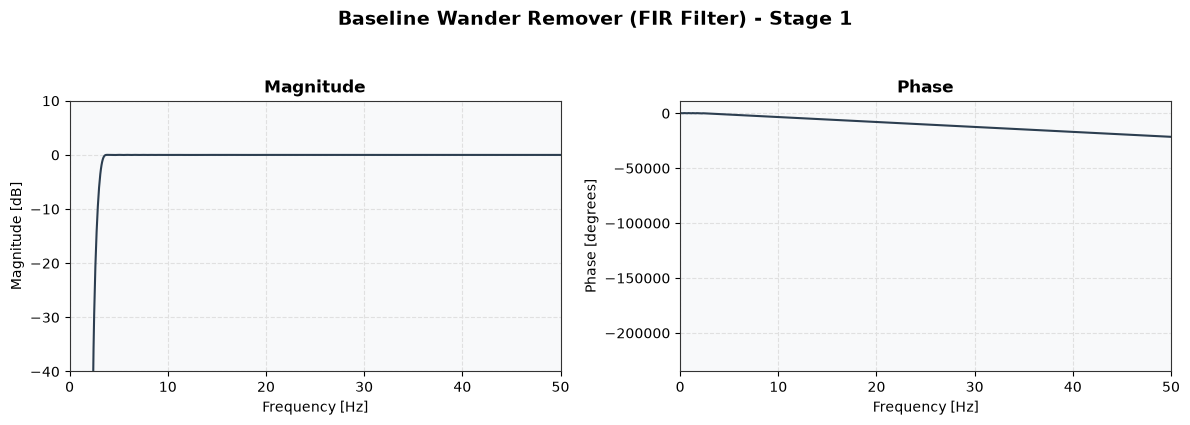

In [3]:
# 1. Baseline Wander Removal (S1 -> S2)
bwr = BaselineWanderRemover(fs=fs_orig)

s1_signal = raw_signal
s2_signal = np.zeros_like(s1_signal)
for ch in range(s1_signal.shape[1]):
    s2_signal[:, ch] = bwr.apply(s1_signal[:, ch])

plot_offset_s = 6.5
plot_samples_orig = int(fs_orig * 3.0) 
plot_offset_orig = int(plot_offset_s * fs_orig)
t_orig = np.arange(plot_samples_orig) / fs_orig
plot_filter_transfer_function(bwr.taps, 1.0, fs_orig,
                               title="Baseline Wander Remover (FIR Filter) - Stage 1")

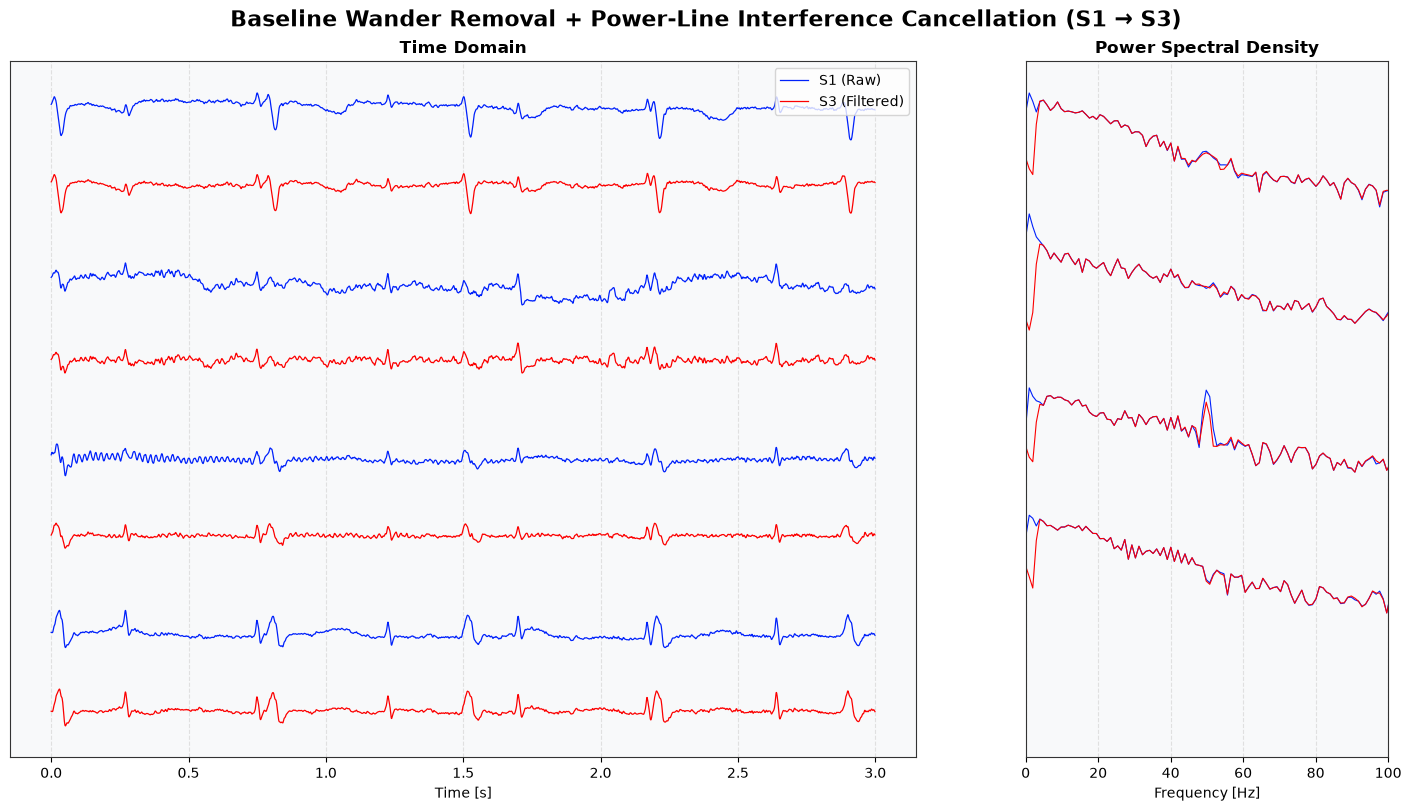

In [4]:
# 2. Power-Line Interference Cancellation (S2 -> S3)
plc_std = AdaptivePLICanceller(fs=fs_orig)
plc = AdaptivePLICanceller(fs=fs_orig, num_harmonics=4)

s3_signal = np.zeros_like(s2_signal)
for ch in range(s2_signal.shape[1]):
    s3_signal[:, ch] = plc.apply(s2_signal[:, ch])

# BWR + PLC (S1 -> S3) plotting
plot_before_after_comprehensive(t_orig, s1_signal[plot_offset_orig:plot_offset_orig+plot_samples_orig, :],
                           s3_signal[plot_offset_orig:plot_offset_orig+plot_samples_orig, :], fs_orig,
                           title="Baseline Wander Removal + Power-Line Interference Cancellation (S1 → S3)")

In [5]:
# 3. Upsampling to 2000Hz (S4)
fs_target = 2000.0
resampler = SignalResampler(original_fs=fs_orig, target_fs=fs_target)
s4_signal = resampler.upsample(s3_signal.T).T

plot_offset_target = int(plot_offset_s * fs_target)

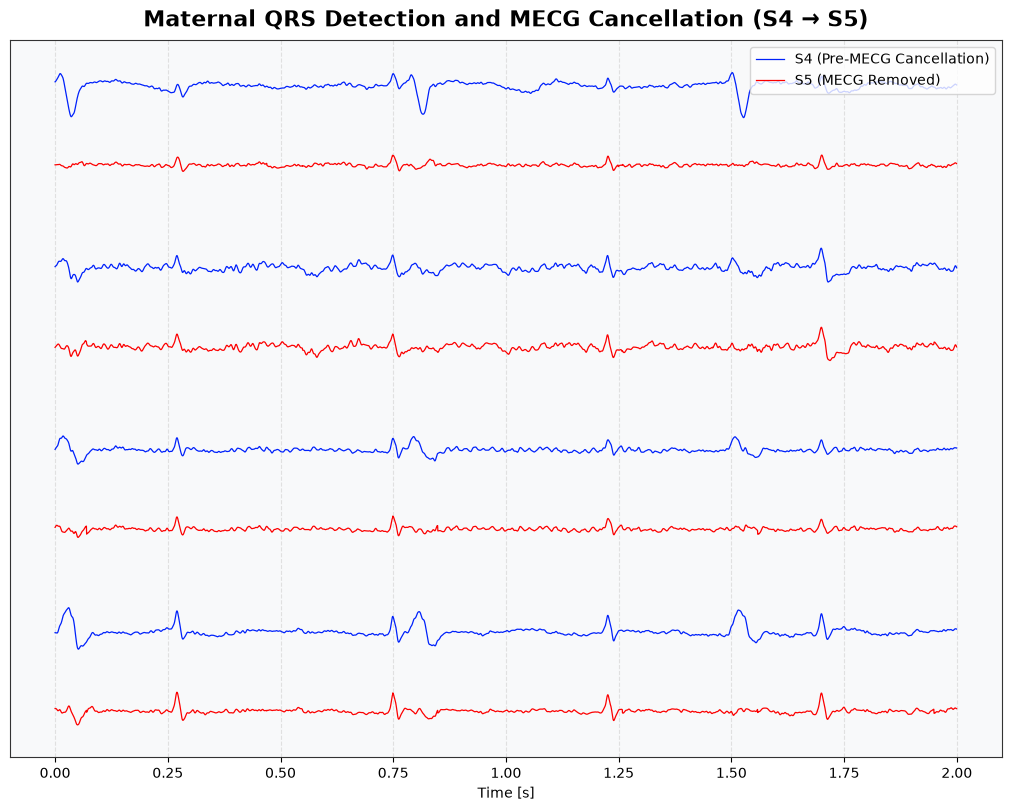

In [6]:
# 4. Maternal QRS Detection and MECG Cancellation (S4 -> S5)
mecg_canc = MECGCanceller(fs=fs_target)
s5_signal = mecg_canc.apply(s4_signal)

plot_samples_2s = int(fs_target * 2.0) 
t_2s = np.arange(plot_samples_2s) / fs_target

plot_before_after_comprehensive(t_2s, s4_signal[plot_offset_target:plot_offset_target+plot_samples_2s, :],
                           s5_signal[plot_offset_target:plot_offset_target+plot_samples_2s, :], fs_target,
                           title="Maternal QRS Detection and MECG Cancellation (S4 → S5)",
                           before_label="S4 (Pre-MECG Cancellation)", after_label="S5 (MECG Removed)",
                           show_psd=False)

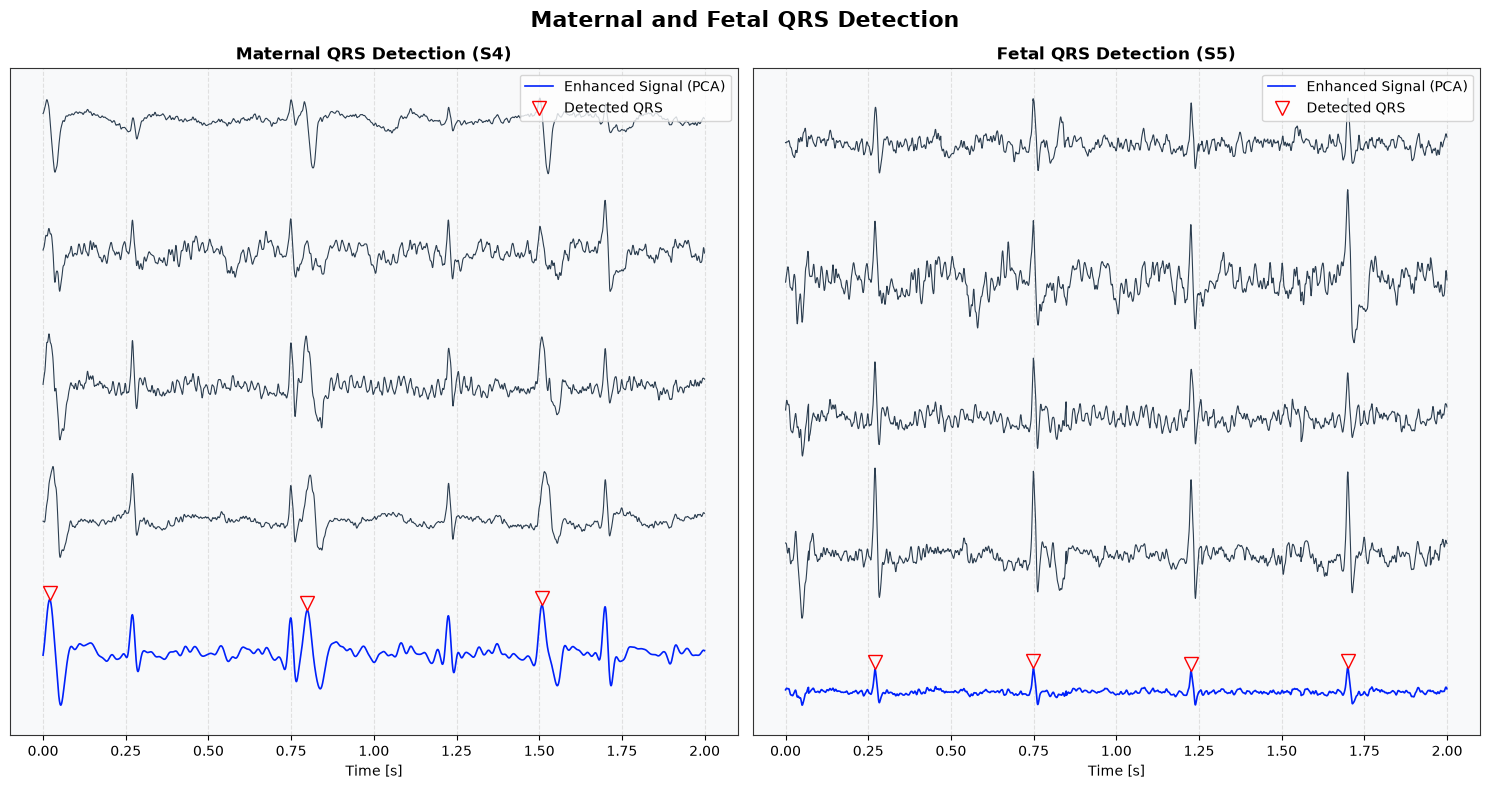

In [7]:
# 5. Maternal QRS Detection (S4) and Fetal QRS Detection / FECG Extraction (S6)
fecg_ext = FECGExtractor(fs=fs_target)

# Multi-channel QRS enhancement (PCA) and fetal QRS detection
fetal_enhanced = fecg_ext.enhance_fetal_qrs(s5_signal)
fetal_peaks = fecg_ext.detect_fetal_qrs(s5_signal)

fetal_peaks_window = fetal_peaks[(fetal_peaks >= plot_offset_target) &
                                  (fetal_peaks < plot_offset_target + plot_samples_2s)] - plot_offset_target

# Multi-channel QRS enhancement (PCA) and maternal QRS detection (on S4, pre-cancellation)
maternal_enhanced = mecg_canc.enhance_maternal_qrs(s4_signal)
maternal_peaks = mecg_canc.detect_maternal_qrs(s4_signal)

maternal_peaks_window = maternal_peaks[(maternal_peaks >= plot_offset_target) &
                                        (maternal_peaks < plot_offset_target + plot_samples_2s)] - plot_offset_target

plot_qrs_detection_dual(t_2s,
                        s4_signal[plot_offset_target:plot_offset_target+plot_samples_2s, :],
                        maternal_enhanced[plot_offset_target:plot_offset_target+plot_samples_2s],
                        maternal_peaks_window,
                        s5_signal[plot_offset_target:plot_offset_target+plot_samples_2s, :],
                        fetal_enhanced[plot_offset_target:plot_offset_target+plot_samples_2s],
                        fetal_peaks_window,
                        maternal_title="Maternal QRS Detection (S4)",
                        fetal_title="Fetal QRS Detection (S5)")

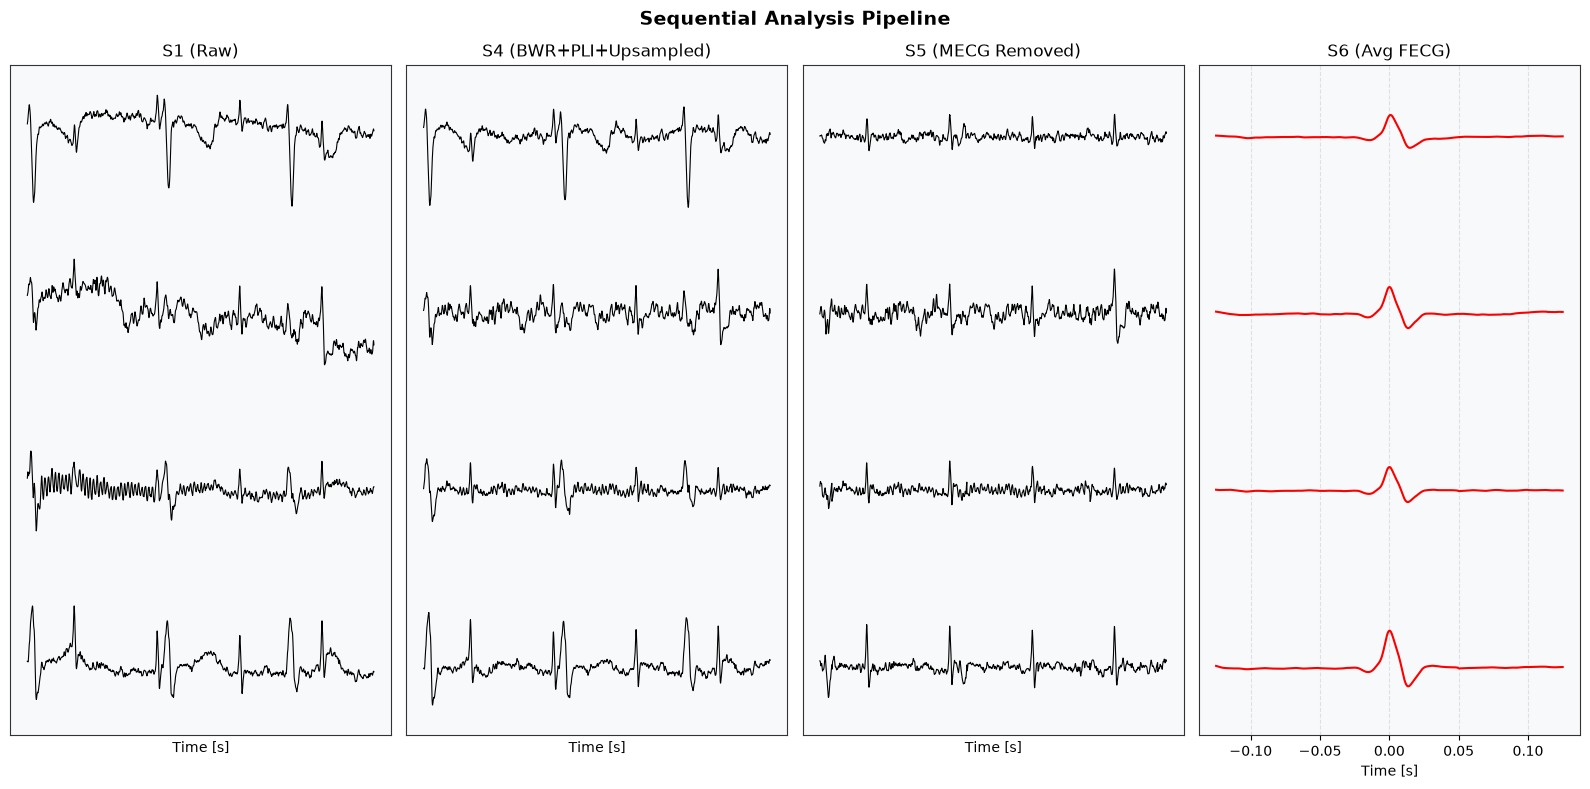

In [8]:
# 6. Synchronous averaging of fetal beats to obtain the average fetal beat morphology (S6)
s6_avg_beat = fecg_ext.synchronous_averaging(s5_signal, fetal_peaks, window_size_sec=0.25)
if s6_avg_beat is None:
    s6_avg_beat = np.zeros((int(0.25 * fs_target), s5_signal.shape[1]))

s1_resampled = resampler.upsample(raw_signal.T).T

plot_pipeline_stages(t_2s, s1_resampled[plot_offset_target:plot_offset_target+plot_samples_2s, :],
                     s4_signal[plot_offset_target:plot_offset_target+plot_samples_2s, :],
                     s5_signal[plot_offset_target:plot_offset_target+plot_samples_2s, :],
                     s6_avg_beat)

## Detection Validation Against Ground Truth

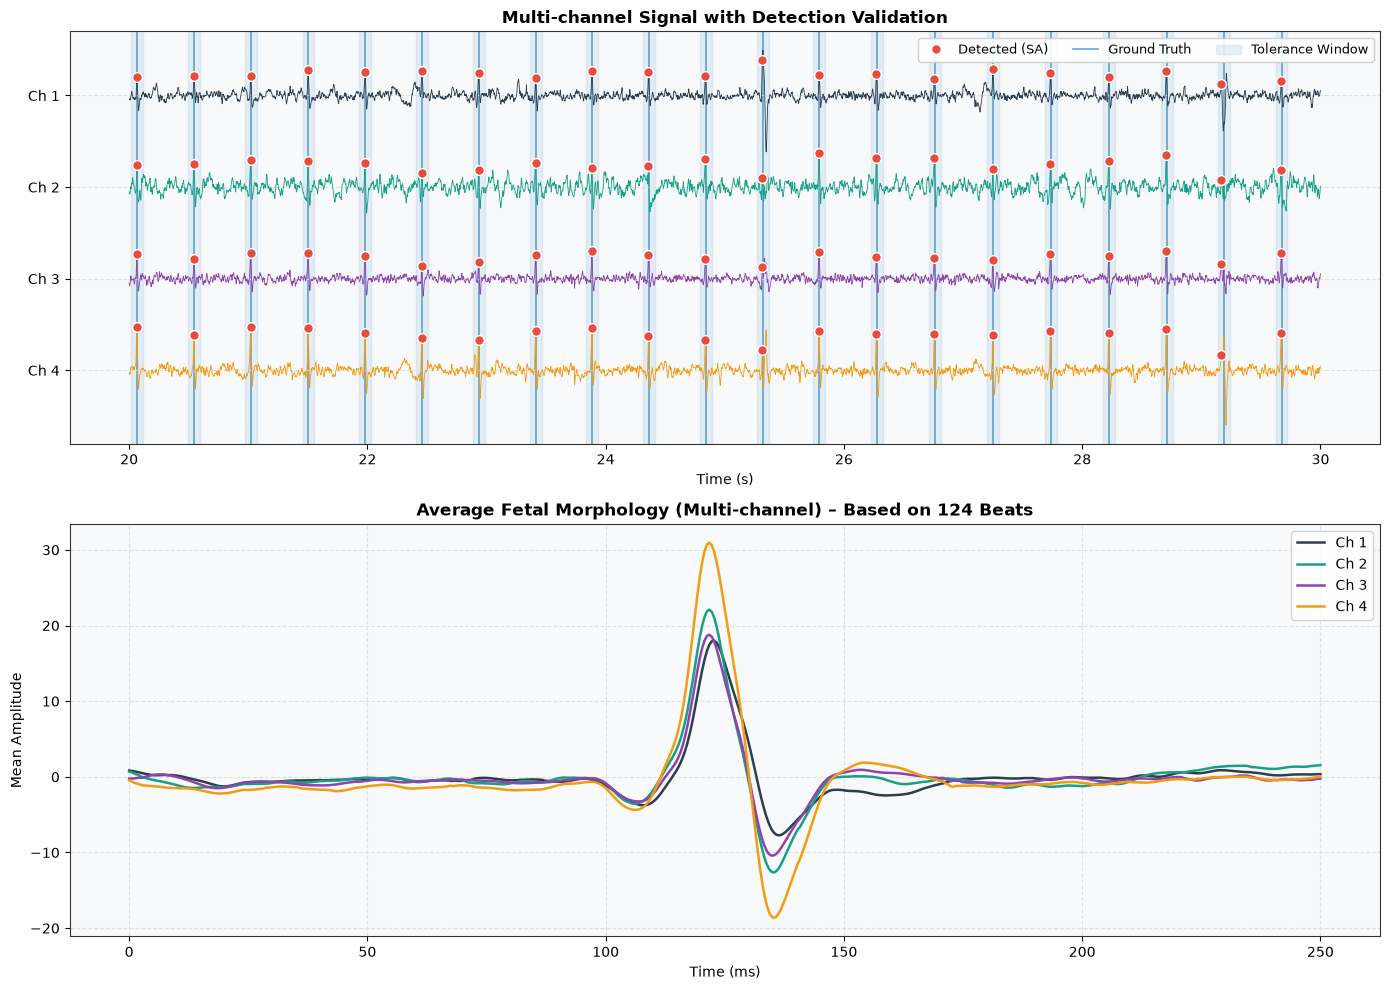

In [9]:
gt_peaks = load_ground_truth_peaks(data_dir, target_record, fs_target)

zoom_start = int(20.0 * fs_target)
zoom_end = int(30.0 * fs_target)
t_zoom = np.arange(zoom_start, zoom_end) / fs_target
channels_zoom = s5_signal[zoom_start:zoom_end, :]

detected_zoom = fetal_peaks[(fetal_peaks >= zoom_start) & (fetal_peaks < zoom_end)] - zoom_start
gt_zoom = gt_peaks[(gt_peaks >= zoom_start) & (gt_peaks < zoom_end)] - zoom_start

half_win = int(0.125 * fs_target)
n_beats_gt = sum(1 for p in gt_peaks if p - half_win >= 0 and p + half_win <= len(s5_signal))
gt_avg_beat = fecg_ext.synchronous_averaging(s5_signal, gt_peaks, window_size_sec=0.25)
if gt_avg_beat is None:
    gt_avg_beat = np.zeros((2 * half_win, s5_signal.shape[1]))
t_avg_ms = np.linspace(0, 250, len(gt_avg_beat))

plot_detection_validation(t_zoom, channels_zoom, detected_zoom, gt_zoom,
                          t_avg_ms, gt_avg_beat, n_beats_gt)

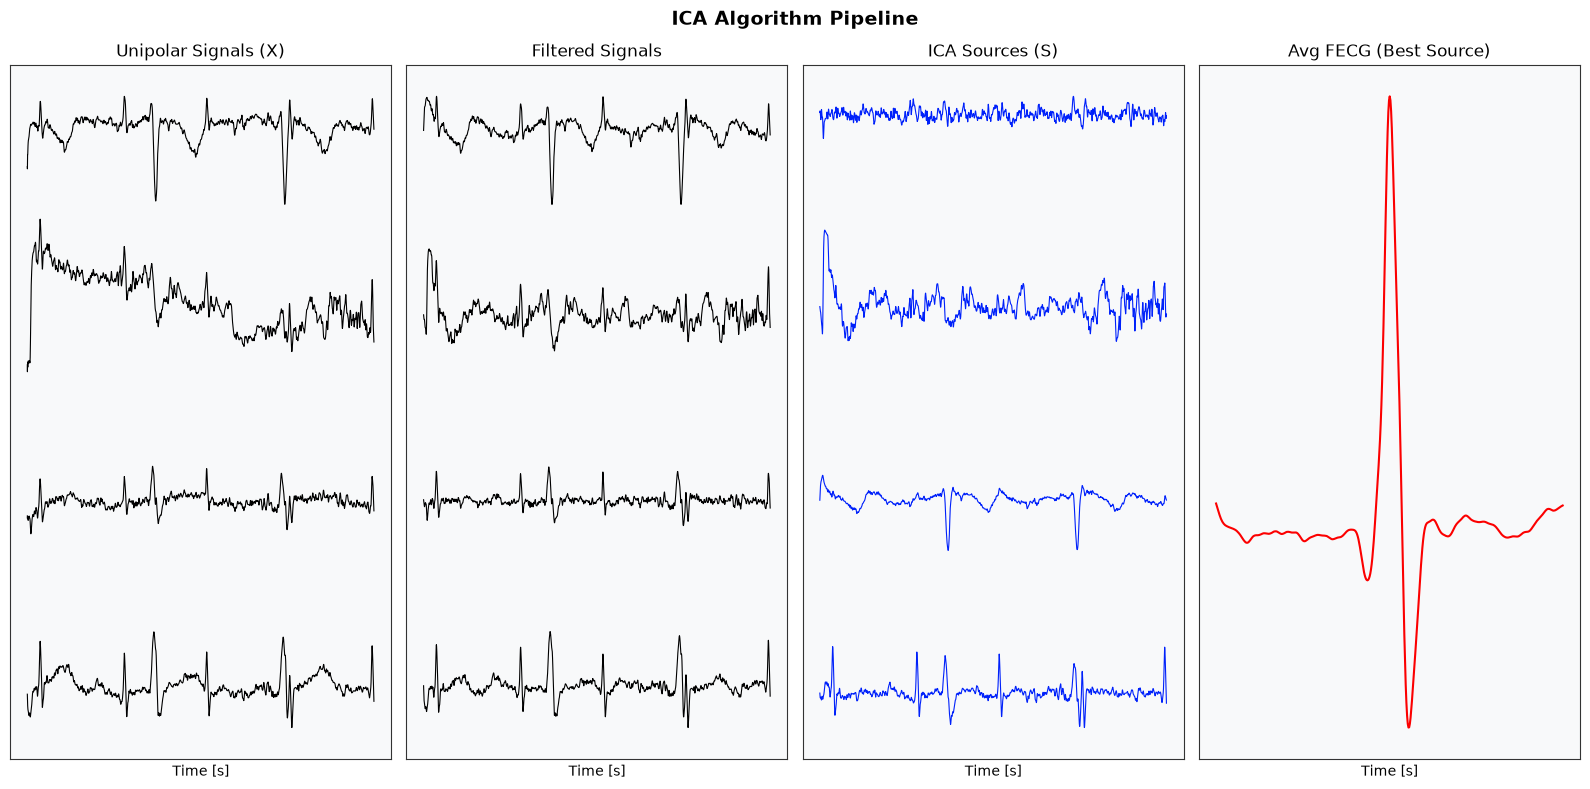

In [10]:
# 7. ICA for FECG Extraction - FastICA 
ica = FastICA(n_components=s3_signal.shape[1], random_state=42, whiten='unit-variance')
ica_sources_orig = ica.fit_transform(s3_signal)
ica_sources = resampler.upsample(ica_sources_orig.T).T

# The QRS detector is applied to every component and the one yielding the most physiologically valid FHR points is selected as the best fetal ECG source.
fhr_point_counts = [len(compute_fhr(fecg_ext.detect_fetal_qrs(ica_sources[:, i].reshape(-1, 1)), fs_target, std=USE_STD_FHR_BOUNDS))
                     for i in range(ica_sources.shape[1])]
best_fecg_idx = int(np.argmax(fhr_point_counts))
best_fecg_source = ica_sources[:, best_fecg_idx].reshape(-1, 1) 

fetal_peaks_ica = fecg_ext.detect_fetal_qrs(best_fecg_source)
best_fecg_avg = fecg_ext.synchronous_averaging(best_fecg_source, fetal_peaks_ica, window_size_sec=0.25)
if best_fecg_avg is None:
    best_fecg_avg = np.zeros((int(0.25 * fs_target), 1))

plot_ica_stages(t_2s, s1_resampled[:plot_samples_2s, :], 
                 s4_signal[:plot_samples_2s, :], 
                 ica_sources[:plot_samples_2s, :], 
                 best_fecg_avg)

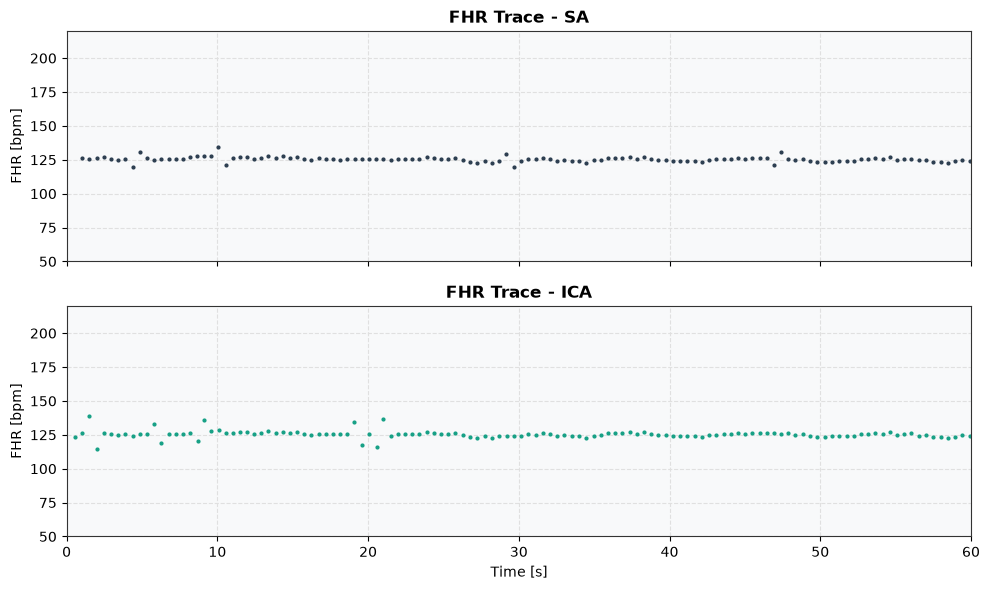

Valid SA points: 124, FHR range: 119.5219123505976 - 134.52914798206277
Valid ICA points: 125, FHR range: 114.7227533460803 - 139.04982618771726


In [11]:
# Compute FHR for SA and ICA over a 60-second window
samples_60s = int(fs_target * 60.0)

# Limit peaks to the first 60 seconds
peaks_sa_60s = fetal_peaks[fetal_peaks < samples_60s]
peaks_ica_60s = fetal_peaks_ica[fetal_peaks_ica < samples_60s]

fhr_sa = compute_fhr(peaks_sa_60s, fs_target, std=USE_STD_FHR_BOUNDS)
fhr_ica = compute_fhr(peaks_ica_60s, fs_target, std=USE_STD_FHR_BOUNDS)

if len(fhr_sa) > 0 and len(fhr_ica) > 0:
    t_fhr_sa = (peaks_sa_60s[1:] / fs_target)[-len(fhr_sa):]
    t_fhr_ica = (peaks_ica_60s[1:] / fs_target)[-len(fhr_ica):]

    plot_fhr_traces(t_fhr_sa, fhr_sa, t_fhr_ica, fhr_ica)
else:
    print("Insufficient peaks to plot the FHR.")

print(f"Valid SA points: {len(fhr_sa)}, FHR range: {min(fhr_sa) if len(fhr_sa) > 0 else 'N/A'} - {max(fhr_sa) if len(fhr_sa) > 0 else 'N/A'}")
print(f"Valid ICA points: {len(fhr_ica)}, FHR range: {min(fhr_ica) if len(fhr_ica) > 0 else 'N/A'} - {max(fhr_ica) if len(fhr_ica) > 0 else 'N/A'}")

## Performance Measures 

FHR detection success rate (>= 60% coverage) -- SA: 96.0%  |  ICA: 96.0%
Mean FHR coverage across patients -- SA: 0.87  |  ICA: 0.92
Mean FHR reliability (feasible patients only) -- SA: 0.755  |  ICA: 0.683
Mean SNR (dB) across patients -- mean: -4.9  min: -11.0  max: 1.3
Mean SIR (dB) across patients -- mean: -12.0  min: -22.5  max: 0.5


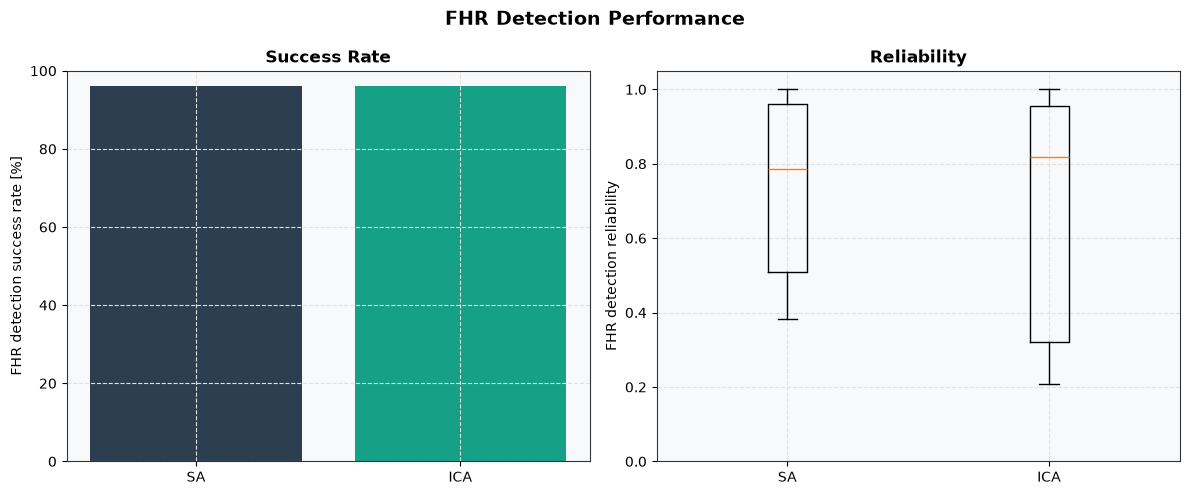

In [12]:
# FHR detection success rate & reliability over all records
results = []
for record_name, rec_data in all_records_data.items():
    sig, fs_rec = rec_data['signal'], rec_data['fs']

    s1 = sig
    s2 = np.zeros_like(s1)
    for ch in range(s1.shape[1]):
        s2[:, ch] = bwr.apply(s1[:, ch])
    s3 = np.zeros_like(s2)
    for ch in range(s2.shape[1]):
        s3[:, ch] = plc_std.apply(s2[:, ch])

    # SA
    s4 = resampler.upsample(s3.T).T
    s5 = mecg_canc.apply(s4)
    peaks_sa = fecg_ext.detect_fetal_qrs(s5)
    fhr_sa = compute_fhr(peaks_sa, fs_target, std=USE_STD_FHR_BOUNDS)
    t_sa = (peaks_sa[1:] / fs_target)[-len(fhr_sa):] if len(fhr_sa) else np.array([])
    coverage_sa = compute_fhr_coverage(peaks_sa, fs_target, s5.shape[0] / fs_target, std=USE_STD_FHR_BOUNDS)

    # SNR/SIR for SA
    s6 = fecg_ext.synchronous_averaging(s5, peaks_sa, window_size_sec=0.25) if len(peaks_sa) else None
    if s6 is not None:
        snr_db, sir_db = compute_snr_sir(s4, s5, s6, peaks_sa, fs_target, window_size_sec=0.25)
        mean_snr_db, mean_sir_db = np.mean(snr_db), np.mean(sir_db)
    else:
        mean_snr_db, mean_sir_db = np.nan, np.nan

    # ICA 
    ica_eval = FastICA(n_components=s3.shape[1], random_state=42, whiten='unit-variance')
    sources_orig = ica_eval.fit_transform(s3)
    sources = resampler.upsample(sources_orig.T).T
    counts = [len(compute_fhr(fecg_ext.detect_fetal_qrs(sources[:, i].reshape(-1, 1)), fs_target, std=USE_STD_FHR_BOUNDS)) 
              for i in range(sources.shape[1])]
    best = sources[:, int(np.argmax(counts))].reshape(-1, 1)
    peaks_ica = fecg_ext.detect_fetal_qrs(best)
    fhr_ica = compute_fhr(peaks_ica, fs_target, std=USE_STD_FHR_BOUNDS)
    t_ica = (peaks_ica[1:] / fs_target)[-len(fhr_ica):] if len(fhr_ica) else np.array([])
    coverage_ica = compute_fhr_coverage(peaks_ica, fs_target, best.shape[0] / fs_target, std=USE_STD_FHR_BOUNDS)

    # A record is a detection "success" if at least MIN_FHR_COVERAGE of its duration is covered by physiologically valid, RR-interval-derived FHR estimates.
    results.append({
        'record': record_name,
        'coverage_sa': coverage_sa,
        'coverage_ica': coverage_ica,
        'feasible_sa': coverage_sa >= MIN_FHR_COVERAGE,
        'feasible_ica': coverage_ica >= MIN_FHR_COVERAGE,
        'reliability_sa': compute_fhr_reliability(fhr_sa, t_sa),
        'reliability_ica': compute_fhr_reliability(fhr_ica, t_ica),
        'mean_snr_db': mean_snr_db,
        'mean_sir_db': mean_sir_db,
    })

df_results = pd.DataFrame(results)
success_rate_sa = compute_success_rate(df_results['feasible_sa'])
success_rate_ica = compute_success_rate(df_results['feasible_ica'])

print(f"FHR detection success rate (>= {MIN_FHR_COVERAGE:.0%} coverage) -- "
      f"SA: {success_rate_sa:.1f}%  |  ICA: {success_rate_ica:.1f}%")
print(f"Mean FHR coverage across patients -- "
      f"SA: {df_results['coverage_sa'].mean():.2f}  |  ICA: {df_results['coverage_ica'].mean():.2f}")
print(f"Mean FHR reliability (feasible patients only) -- "
      f"SA: {df_results.loc[df_results['feasible_sa'], 'reliability_sa'].mean():.3f}  |  "
      f"ICA: {df_results.loc[df_results['feasible_ica'], 'reliability_ica'].mean():.3f}")
print(f"Mean SNR (dB) across patients -- "
      f"mean: {df_results['mean_snr_db'].mean():.1f}  "
      f"min: {df_results['mean_snr_db'].min():.1f}  max: {df_results['mean_snr_db'].max():.1f}")
print(f"Mean SIR (dB) across patients -- "
      f"mean: {df_results['mean_sir_db'].mean():.1f}  "
      f"min: {df_results['mean_sir_db'].min():.1f}  max: {df_results['mean_sir_db'].max():.1f}")

plot_performance_summary(df_results, success_rate_sa, success_rate_ica)

### SNR/SIR vs Reliability

FHR detection reliability as a function of the estimated SNR and SIR, one row per method. Unsuccessful cases are plotted at reliability = 0.

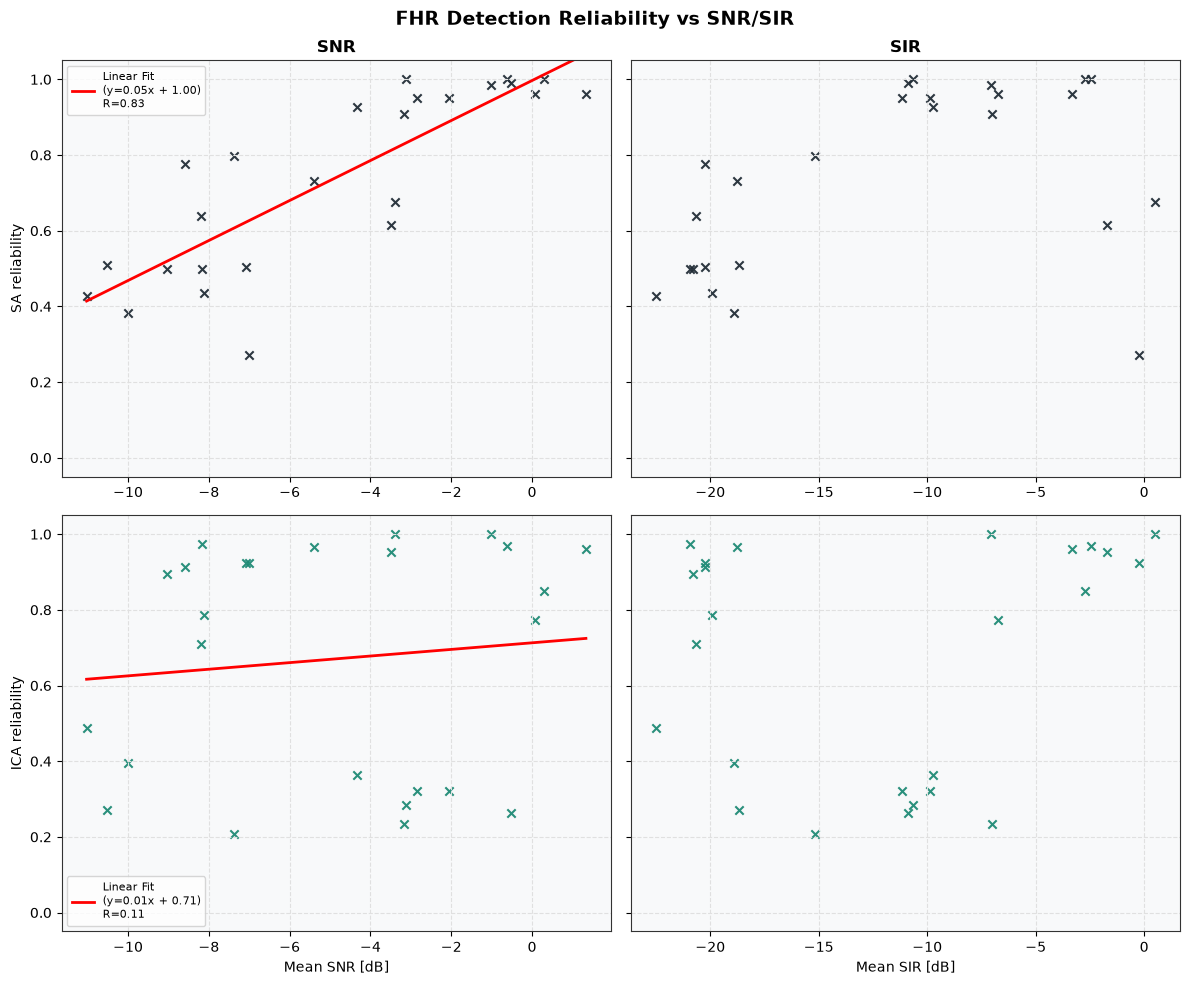

In [13]:
df_fig10 = df_results.dropna(subset=['mean_snr_db', 'mean_sir_db']).copy()
df_fig10['reliability_sa_fig10'] = df_fig10['reliability_sa'].fillna(0.0)
df_fig10['reliability_ica_fig10'] = df_fig10['reliability_ica'].fillna(0.0)

plot_snr_sir_vs_reliability(df_fig10)

### Correlation Analysis: Reliability vs SNR/SIR

Spearman's rank correlation between per-record reliability and mean SNR/SIR, computed separately for SA and ICA, to test whether the paper's qualitative Fig. 10 claim (SNR/SIR predicts reliability, especially for ICA) holds up quantitatively -- and to compare how strongly each method's reliability tracks signal quality. Visualised here as a Spearman correlation matrix.

Reliability vs SNR/SIR correlation (n=25 records with valid SNR/SIR)
method predictor  spearman_rho  p_value
    SA       SNR         0.833    0.000
    SA       SIR         0.476    0.016
   ICA       SNR         0.111    0.597
   ICA       SIR         0.196    0.347


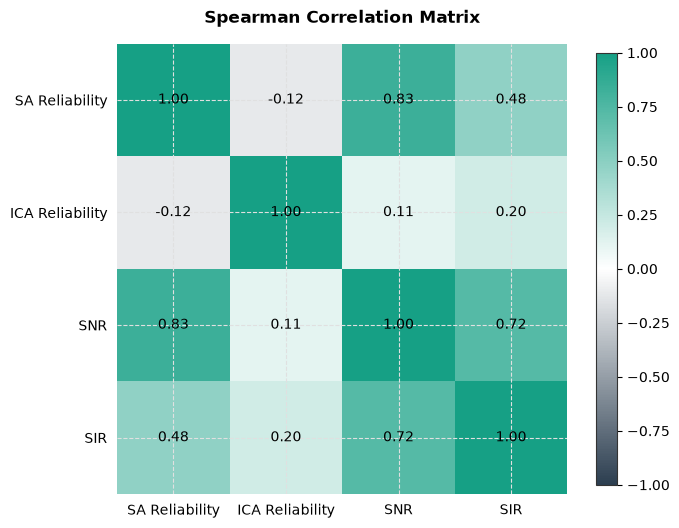

In [14]:
# Spearman's rho between reliability and SNR/SIR, separately for SA and ICA.
corr_rows = []
for method, rel_col in [('SA', 'reliability_sa_fig10'), ('ICA', 'reliability_ica_fig10')]:
    for predictor, pred_col in [('SNR', 'mean_snr_db'), ('SIR', 'mean_sir_db')]:
        rho, p_value, _, _ = spearman_with_ci(df_fig10[pred_col], df_fig10[rel_col], random_state=42)
        corr_rows.append({'method': method, 'predictor': predictor, 'spearman_rho': rho, 'p_value': p_value})

df_corr = pd.DataFrame(corr_rows)
print(f"Reliability vs SNR/SIR correlation (n={len(df_fig10)} records with valid SNR/SIR)")
print(df_corr.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

plot_reliability_correlation_matrix(df_fig10)

### Validation Against Ground Truth

Detected fetal QRS locations (for both SA and ICA) are matched against the true ones here, across the full 25-record set, to get **precision / recall / F1**, and the resulting FHR trace (bpm) is compared directly against a ground-truth FHR trace derived from the `.fqrs` RR intervals to get **MAE / RMSE**.

Ground-truth validation over 25 records (50 ms tolerance)
SA  -- precision: 77.5%  recall: 67.3%  F1: 72.0%
ICA -- precision: 59.6%  recall: 53.1%  F1: 56.2%

FHR-value accuracy vs. ground truth (bpm, mean over the 25 records)
SA  -- MAE: 13.55 bpm  RMSE: 17.57 bpm  (mean grid overlap with GT: 96%)
ICA -- MAE: 17.38 bpm  RMSE: 21.39 bpm  (mean grid overlap with GT: 98%)


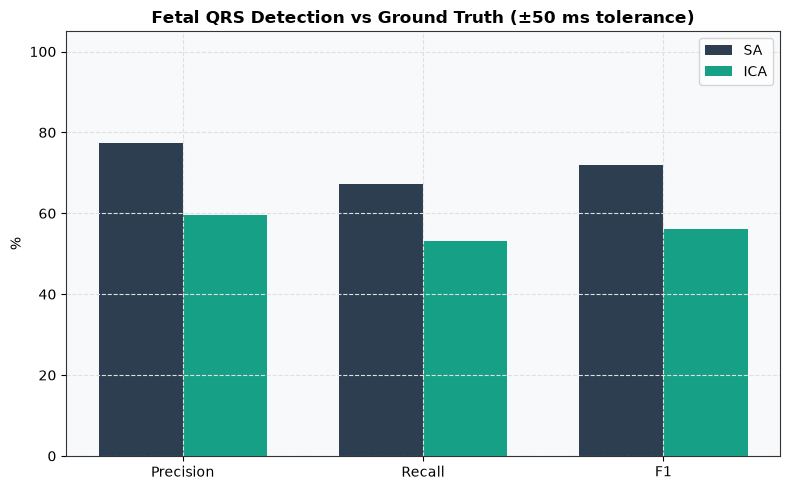

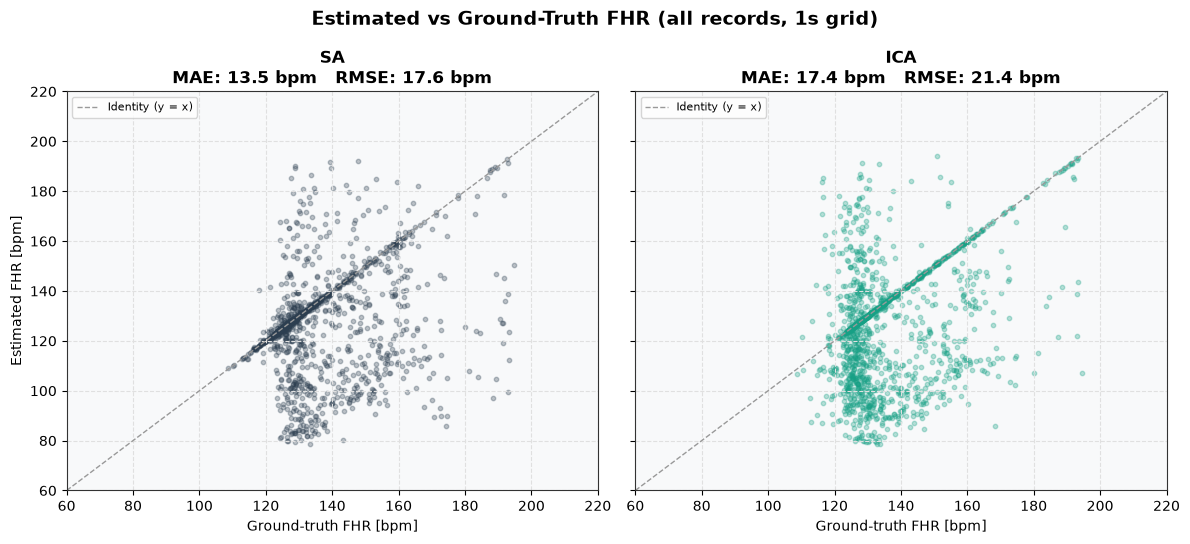

In [15]:
gt_tolerance_ms = 50.0
gt_tolerance = int((gt_tolerance_ms / 1000.0) * fs_target)

gt_results = []
detected_peaks_by_record = {}
gt_grid_sa, est_grid_sa = [], []
gt_grid_ica, est_grid_ica = [], []
for record_name, rec_data in all_records_data.items():
    sig, fs_rec = rec_data['signal'], rec_data['fs']
    gt_peaks_rec = load_ground_truth_peaks(data_dir, record_name, fs_target)

    s1 = sig
    s2 = np.zeros_like(s1)
    for ch in range(s1.shape[1]):
        s2[:, ch] = bwr.apply(s1[:, ch])
    s3 = np.zeros_like(s2)
    for ch in range(s2.shape[1]):
        s3[:, ch] = plc_std.apply(s2[:, ch])

    # SA
    s4 = resampler.upsample(s3.T).T
    s5 = mecg_canc.apply(s4)
    peaks_sa = fecg_ext.detect_fetal_qrs(s5)

    # ICA 
    ica_eval = FastICA(n_components=s3.shape[1], random_state=42, whiten='unit-variance')
    sources_orig = ica_eval.fit_transform(s3)
    sources = resampler.upsample(sources_orig.T).T
    counts = [len(compute_fhr(fecg_ext.detect_fetal_qrs(sources[:, i].reshape(-1, 1)), fs_target, std=USE_STD_FHR_BOUNDS))
              for i in range(sources.shape[1])]
    best = sources[:, int(np.argmax(counts))].reshape(-1, 1)
    peaks_ica = fecg_ext.detect_fetal_qrs(best)

    detected_peaks_by_record[record_name] = {
        'sa': peaks_sa, 'ica': peaks_ica, 'gt': gt_peaks_rec,
    }

    # Match detected peaks to ground truth and compute TP, FP, FN
    tp_sa, fp_sa, fn_sa = match_peaks_to_gt(peaks_sa, gt_peaks_rec, gt_tolerance)
    tp_ica, fp_ica, fn_ica = match_peaks_to_gt(peaks_ica, gt_peaks_rec, gt_tolerance)

    # FHR-value (bpm) accuracy vs. ground truth: both traces are interpolated onto a common time
    # grid and compared, since detected and ground-truth peaks generally fall at different instants.
    gt_times, gt_fhr = compute_fhr_series(gt_peaks_rec, fs_target, std=USE_STD_FHR_BOUNDS)
    sa_times, sa_fhr = compute_fhr_series(peaks_sa, fs_target, std=USE_STD_FHR_BOUNDS)
    ica_times, ica_fhr = compute_fhr_series(peaks_ica, fs_target, std=USE_STD_FHR_BOUNDS)
    duration_sec = s5.shape[0] / fs_target

    mae_sa, rmse_sa, overlap_sa, gt_on_grid_sa, est_on_grid_sa = compute_fhr_mae_rmse(
        gt_times, gt_fhr, sa_times, sa_fhr, duration_sec)
    mae_ica, rmse_ica, overlap_ica, gt_on_grid_ica, est_on_grid_ica = compute_fhr_mae_rmse(
        gt_times, gt_fhr, ica_times, ica_fhr, duration_sec)
    gt_grid_sa.append(gt_on_grid_sa); est_grid_sa.append(est_on_grid_sa)
    gt_grid_ica.append(gt_on_grid_ica); est_grid_ica.append(est_on_grid_ica)

    gt_results.append({
        'record': record_name, 'n_gt': len(gt_peaks_rec),
        'tp_sa': tp_sa, 'fp_sa': fp_sa, 'fn_sa': fn_sa,
        'tp_ica': tp_ica, 'fp_ica': fp_ica, 'fn_ica': fn_ica,
        'mae_sa': mae_sa, 'rmse_sa': rmse_sa, 'overlap_sa': overlap_sa,
        'mae_ica': mae_ica, 'rmse_ica': rmse_ica, 'overlap_ica': overlap_ica,
    })

# Precision, recall, and F1-score for SA and ICA
df_gt = pd.DataFrame(gt_results)
prec_sa, rec_sa, f1_sa = precision_recall_f1(df_gt['tp_sa'].sum(), df_gt['fp_sa'].sum(), df_gt['fn_sa'].sum())
prec_ica, rec_ica, f1_ica = precision_recall_f1(df_gt['tp_ica'].sum(), df_gt['fp_ica'].sum(), df_gt['fn_ica'].sum())

print(f"Ground-truth validation over {len(df_gt)} records ({gt_tolerance_ms:.0f} ms tolerance)")
print(f"SA  -- precision: {prec_sa*100:.1f}%  recall: {rec_sa*100:.1f}%  F1: {f1_sa*100:.1f}%")
print(f"ICA -- precision: {prec_ica*100:.1f}%  recall: {rec_ica*100:.1f}%  F1: {f1_ica*100:.1f}%")

print(f"\nFHR-value accuracy vs. ground truth (bpm, mean over the 25 records)")
print(f"SA  -- MAE: {df_gt['mae_sa'].mean():.2f} bpm  RMSE: {df_gt['rmse_sa'].mean():.2f} bpm  "
      f"(mean grid overlap with GT: {df_gt['overlap_sa'].mean():.0%})")
print(f"ICA -- MAE: {df_gt['mae_ica'].mean():.2f} bpm  RMSE: {df_gt['rmse_ica'].mean():.2f} bpm  "
      f"(mean grid overlap with GT: {df_gt['overlap_ica'].mean():.0%})")

plot_ground_truth_validation(prec_sa, rec_sa, f1_sa, prec_ica, rec_ica, f1_ica, gt_tolerance_ms)
plot_fhr_accuracy(np.concatenate(gt_grid_sa), np.concatenate(est_grid_sa), df_gt['mae_sa'].mean(), df_gt['rmse_sa'].mean(),
                  np.concatenate(gt_grid_ica), np.concatenate(est_grid_ica), df_gt['mae_ica'].mean(), df_gt['rmse_ica'].mean())

### Full Per-Record Results Table

All 25 records, SNR, SIR, reliability, precision, recall, F1 and FHR MAE/RMSE for SA and ICA.

In [16]:
prf_sa = list(df_gt.apply(lambda r: precision_recall_f1(r['tp_sa'], r['fp_sa'], r['fn_sa']), axis=1))
df_gt['precision_sa'], df_gt['recall_sa'], df_gt['f1_sa'] = zip(*prf_sa)

prf_ica = list(df_gt.apply(lambda r: precision_recall_f1(r['tp_ica'], r['fp_ica'], r['fn_ica']), axis=1))
df_gt['precision_ica'], df_gt['recall_ica'], df_gt['f1_ica'] = zip(*prf_ica)

df_per_record = df_results.merge(df_gt, on='record')[[
    'record', 'mean_snr_db', 'mean_sir_db',
    'reliability_sa', 'precision_sa', 'recall_sa', 'f1_sa', 'mae_sa', 'rmse_sa',
    'reliability_ica', 'precision_ica', 'recall_ica', 'f1_ica', 'mae_ica', 'rmse_ica',
]].sort_values('record').reset_index(drop=True)

os.makedirs('../results', exist_ok=True)
df_per_record.to_csv('../results/per_record_results.csv', index=False)

print(f"Full per-record results ({len(df_per_record)} records)")
print(df_per_record.round(3).to_string(index=False))


Full per-record results (25 records)
record  mean_snr_db  mean_sir_db  reliability_sa  precision_sa  recall_sa  f1_sa  mae_sa  rmse_sa  reliability_ica  precision_ica  recall_ica  f1_ica  mae_ica  rmse_ica
   a01       -7.080      -20.258           0.504         0.765      0.717  0.740  15.703   24.863            0.924          1.000       1.000   1.000    0.111     0.149
   a02       -8.600      -20.249           0.776         0.276      0.200  0.232  34.097   37.818            0.912          0.246       0.194   0.217   34.966    38.335
   a03       -1.017       -7.044           0.984         1.000      0.992  0.996   0.464    0.994            1.000          0.208       0.164   0.183   26.867    28.610
   a04        1.333       -3.325           0.961         0.992      0.984  0.988   0.801    3.233            0.961          0.992       1.000   0.996    0.720     3.126
   a05        0.302       -2.715           1.000         1.000      0.992  0.996   0.307    0.926            0.850    

### Tolerance-Sensitivity Sweep

Precision/recall/F1 recomputed at several ground-truth matching tolerances (10/25/50/75/100 ms).

Precision/recall/F1 sensitivity to ground-truth matching tolerance
 tolerance_ms  precision_sa  recall_sa  f1_sa  precision_ica  recall_ica  f1_ica
           10         0.607      0.527  0.564          0.443       0.394   0.417
           25         0.729      0.633  0.678          0.534       0.475   0.503
           50         0.775      0.673  0.720          0.596       0.531   0.562
           75         0.811      0.705  0.754          0.652       0.580   0.614
          100         0.845      0.734  0.785          0.712       0.634   0.671


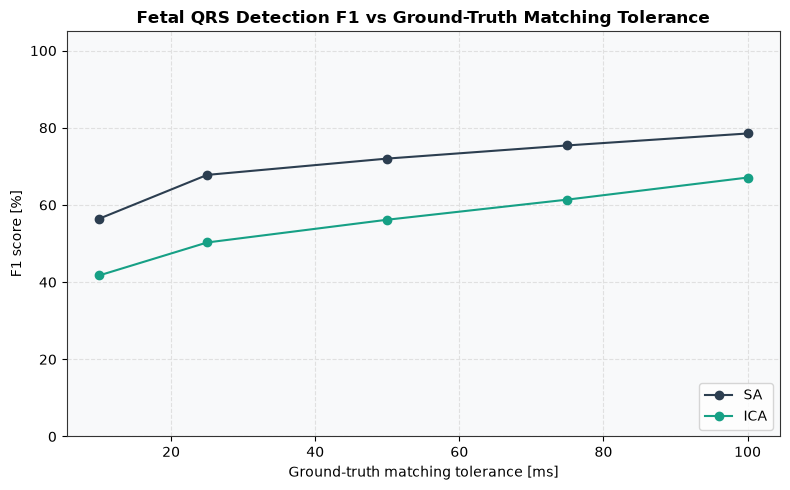

In [17]:
tolerance_sweep_ms = [10, 25, 50, 75, 100]

sweep_rows = []
for tol_ms in tolerance_sweep_ms:
    tol_samples = int((tol_ms / 1000.0) * fs_target)
    tp_sa_total = fp_sa_total = fn_sa_total = 0
    tp_ica_total = fp_ica_total = fn_ica_total = 0
    for peaks in detected_peaks_by_record.values():
        tp_sa, fp_sa, fn_sa = match_peaks_to_gt(peaks['sa'], peaks['gt'], tol_samples)
        tp_ica, fp_ica, fn_ica = match_peaks_to_gt(peaks['ica'], peaks['gt'], tol_samples)
        tp_sa_total += tp_sa; fp_sa_total += fp_sa; fn_sa_total += fn_sa
        tp_ica_total += tp_ica; fp_ica_total += fp_ica; fn_ica_total += fn_ica

    prec_sa_t, rec_sa_t, f1_sa_t = precision_recall_f1(tp_sa_total, fp_sa_total, fn_sa_total)
    prec_ica_t, rec_ica_t, f1_ica_t = precision_recall_f1(tp_ica_total, fp_ica_total, fn_ica_total)
    sweep_rows.append({
        'tolerance_ms': tol_ms,
        'precision_sa': prec_sa_t, 'recall_sa': rec_sa_t, 'f1_sa': f1_sa_t,
        'precision_ica': prec_ica_t, 'recall_ica': rec_ica_t, 'f1_ica': f1_ica_t,
    })

df_tolerance = pd.DataFrame(sweep_rows)
print("Precision/recall/F1 sensitivity to ground-truth matching tolerance")
print(df_tolerance.round(3).to_string(index=False))

plot_tolerance_sensitivity(df_tolerance)
